<a href="https://colab.research.google.com/github/Shreevidhya08/Generative-AI/blob/main/Autoencoders/Autoencoders%20and%20VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AUTOENCODER

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Load MNIST dataset
transform = transforms.ToTensor()

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=64,
                                          shuffle=True)

# Autoencoder Model
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32,128),
            nn.ReLU(),
            nn.Linear(128,28*28),
            nn.Sigmoid()
        )

    def forward(self,x):
        x=x.view(-1,28*28)
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return decoded


model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

# Training
for epoch in range(5):
    for images,_ in trainloader:

        images = images.view(-1,28*28)

        outputs = model(images)
        loss = criterion(outputs,images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:",epoch+1,"Loss:",loss.item())

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.81MB/s]


Epoch: 1 Loss: 0.01771831139922142
Epoch: 2 Loss: 0.010516030713915825
Epoch: 3 Loss: 0.008556713350117207
Epoch: 4 Loss: 0.008870165795087814
Epoch: 5 Loss: 0.009610463865101337


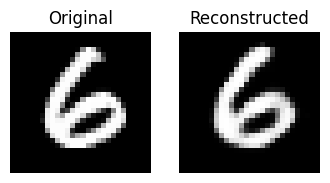

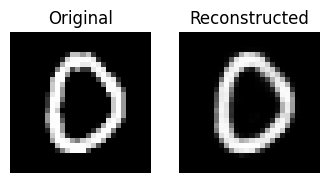

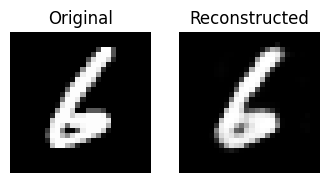

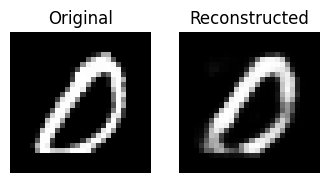

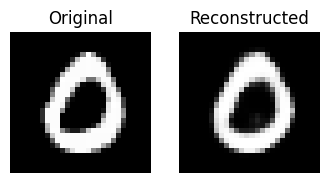

In [5]:
# Get test images
dataiter = iter(trainloader)
images,_ = next(dataiter)

test_images = images[:5]
inputs = test_images.view(-1,28*28)

outputs = model(inputs)
outputs = outputs.view(-1,1,28,28)

# Display images
for i in range(5):

    plt.figure(figsize=(4,2))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(test_images[i].squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Reconstructed")
    plt.imshow(outputs[i].detach().squeeze(), cmap='gray')
    plt.axis("off")

    plt.show()

VARIATIONAL AUTOENCODER

In [6]:
class VAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28,128)
        self.fc_mu = nn.Linear(128,20)
        self.fc_logvar = nn.Linear(128,20)

        self.fc2 = nn.Linear(20,128)
        self.fc3 = nn.Linear(128,28*28)

    def encode(self,x):
        h=torch.relu(self.fc1(x))
        return self.fc_mu(h),self.fc_logvar(h)

    def reparameterize(self,mu,logvar):
        std=torch.exp(0.5*logvar)
        eps=torch.randn_like(std)
        return mu+eps*std

    def decode(self,z):
        h=torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self,x):
        mu,logvar=self.encode(x)
        z=self.reparameterize(mu,logvar)
        return self.decode(z),mu,logvar


vae = VAE()
optimizer = optim.Adam(vae.parameters(),lr=0.001)

# Training
for epoch in range(5):
    for images,_ in trainloader:

        images=images.view(-1,28*28)

        recon,mu,logvar = vae(images)

        recon_loss = nn.functional.mse_loss(recon,images)
        kl_loss = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())

        loss = recon_loss + kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:",epoch+1,"Loss:",loss.item())

Epoch: 1 Loss: 0.07225657254457474
Epoch: 2 Loss: 0.06389476358890533
Epoch: 3 Loss: 0.06815211474895477
Epoch: 4 Loss: 0.06735323369503021
Epoch: 5 Loss: 0.07002944499254227


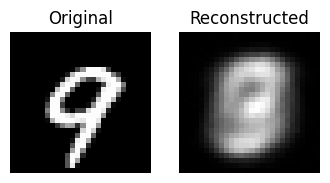

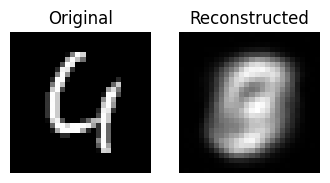

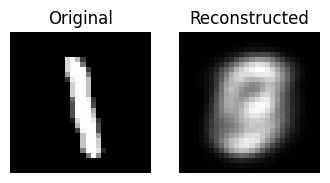

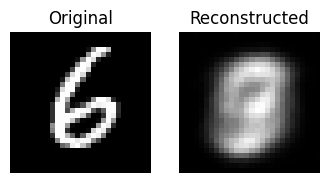

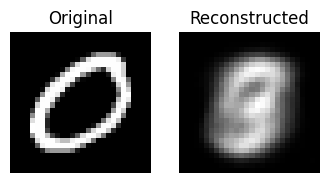

In [7]:
# Testing
dataiter = iter(trainloader)
images,_ = next(dataiter)

test_images = images[:5]
inputs = test_images.view(-1,28*28)

outputs,_,_ = vae(inputs)
outputs = outputs.view(-1,1,28,28)

for i in range(5):

    plt.figure(figsize=(4,2))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(test_images[i].squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Reconstructed")
    plt.imshow(outputs[i].detach().squeeze(), cmap='gray')
    plt.axis("off")

    plt.show()